In [3]:
# ============================================================
# CSE422 Lab Project
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")
#Load Dataset
df = pd.read_csv("/content/Tree_Sterility_Dataset.csv")
print("Dataset Loaded Successfully")
print("Shape of dataset:", df.shape)
df.head()

Dataset Loaded Successfully
Shape of dataset: (2783, 24)


,No,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Soil,Adult,Sterile,...,AMF,EMF,Phenolics,Lignin,NSC,Census,Time,Event,Harvest,Alive
0,126,1,C,Acer saccharum,0.106,Med,2017,Prunus serotina,I,Non-Sterile,...,22.00,NaN,-0.56,13.86,12.15,4,14.0,1.0,NaN,NaN
1,11,1,C,Quercus alba,0.106,Med,2017,Quercus rubra,970,Non-Sterile,...,15.82,31.07,5.19,20.52,19.29,33,115.5,0.0,NaN,X
2,12,1,C,Quercus rubra,0.106,Med,2017,Prunus serotina,J,Non-Sterile,...,24.45,28.19,3.36,24.74,15.01,18,63.0,1.0,NaN,NaN
3,2823,7,D,Acer saccharum,0.080,Med,2016,Prunus serotina,J,Non-Sterile,...,22.23,NaN,-0.71,14.29,12.36,4,14.0,1.0,NaN,NaN
4,5679,14,A,Acer saccharum,0.060,Low,2017,Prunus serotina,689,Non-Sterile,...,21.15,NaN,-0.58,10.85,11.20,4,14.0,1.0,NaN,NaN


In [4]:
print("Dataset Information:")
print(df.info())
print("\nFirst 5 Rows:")
display(df.head())
print("\nStatistical Summary:")
display(df.describe())
print("\nColumn Names:")
print(df.columns)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2783 entries, 0 to 2782
Data columns (total 24 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   No           2783 non-null   int64  
 1   Plot         2783 non-null   int64  
 2   Subplot      2783 non-null   object 
 3   Species      2783 non-null   object 
 4   Light_ISF    2783 non-null   float64
 5   Light_Cat    2783 non-null   object 
 6   Core         2783 non-null   int64  
 7   Soil         2783 non-null   object 
 8   Adult        2783 non-null   object 
 9   Sterile      2783 non-null   object 
 10  Conspecific  2783 non-null   object 
 11  Myco         2783 non-null   object 
 12  SoilMyco     2783 non-null   object 
 13  PlantDate    2783 non-null   object 
 14  AMF          2783 non-null   float64
 15  EMF          1283 non-null   float64
 16  Phenolics    2783 non-null   float64
 17  Lignin       2783 non-null   float64
 18  NSC          2783 non-null 

,No,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Soil,Adult,Sterile,...,AMF,EMF,Phenolics,Lignin,NSC,Census,Time,Event,Harvest,Alive
0,126,1,C,Acer saccharum,0.106,Med,2017,Prunus serotina,I,Non-Sterile,...,22.00,NaN,-0.56,13.86,12.15,4,14.0,1.0,NaN,NaN
1,11,1,C,Quercus alba,0.106,Med,2017,Quercus rubra,970,Non-Sterile,...,15.82,31.07,5.19,20.52,19.29,33,115.5,0.0,NaN,X
2,12,1,C,Quercus rubra,0.106,Med,2017,Prunus serotina,J,Non-Sterile,...,24.45,28.19,3.36,24.74,15.01,18,63.0,1.0,NaN,NaN
3,2823,7,D,Acer saccharum,0.080,Med,2016,Prunus serotina,J,Non-Sterile,...,22.23,NaN,-0.71,14.29,12.36,4,14.0,1.0,NaN,NaN
4,5679,14,A,Acer saccharum,0.060,Low,2017,Prunus serotina,689,Non-Sterile,...,21.15,NaN,-0.58,10.85,11.20,4,14.0,1.0,NaN,NaN



Statistical Summary:


,No,Plot,Light_ISF,Core,AMF,EMF,Phenolics,Lignin,NSC,Census,Time,Event
count,2783.000000,2783.000000,2783.000000,2783.000000,2783.000000,1283.00000,2783.000000,2783.000000,2783.000000,2783.000000,2783.000000,2782.000000
mean,3914.513834,9.561624,0.085707,2016.648940,20.553069,26.47675,1.933105,15.759792,14.219641,15.282070,53.487244,0.570453
std,2253.515063,5.203659,0.025638,0.477387,12.309587,16.63689,1.969842,6.779607,4.298271,9.166555,32.082942,0.495100
min,3.000000,1.000000,0.032000,2016.000000,0.000000,0.00000,-1.350000,2.230000,4.300000,4.000000,14.000000,0.000000
25%,1971.000000,5.000000,0.066000,2016.000000,13.400000,13.78000,0.170000,10.355000,11.605000,7.000000,24.500000,0.000000
50%,3932.000000,10.000000,0.082000,2017.000000,18.000000,27.72000,0.750000,14.040000,12.660000,13.000000,45.500000,1.000000
75%,5879.000000,14.000000,0.100000,2017.000000,24.445000,35.71000,3.780000,21.115000,17.275000,18.000000,63.000000,1.000000
max,7772.000000,18.000000,0.161000,2017.000000,100.000000,87.50000,6.100000,32.770000,29.450000,33.000000,115.500000,1.000000



Column Names:
Index(['No', 'Plot', 'Subplot', 'Species', 'Light_ISF', 'Light_Cat', 'Core',
       'Soil', 'Adult', 'Sterile', 'Conspecific', 'Myco', 'SoilMyco',
       'PlantDate', 'AMF', 'EMF', 'Phenolics', 'Lignin', 'NSC', 'Census',
       'Time', 'Event', 'Harvest', 'Alive'],
      dtype='object')


In [5]:
#Check Missing Values
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percent
})

display(missing_table.sort_values(by="Missing Percentage", ascending=False))

,Missing Values,Missing Percentage
Alive,2292,82.357169
Harvest,2079,74.703557
EMF,1500,53.898670
Event,1,0.035932
No,0,0.000000
Plot,0,0.000000
Subplot,0,0.000000
Species,0,0.000000
Soil,0,0.000000
Core,0,0.000000


Unique values in Event column:
[ 1.  0. nan]

Class Distribution:
Event
1.0    1587
0.0    1195
Name: count, dtype: int64


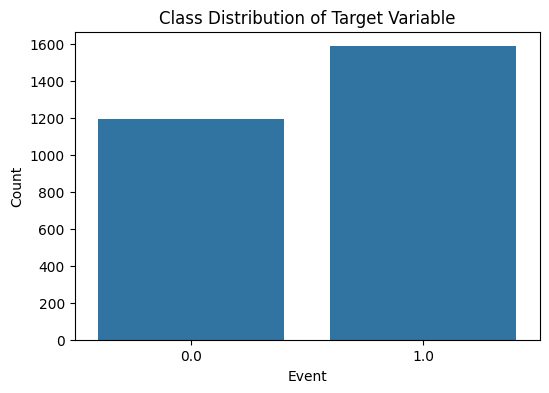

In [6]:
#Check Target Variable
#Target column = Event
print("Unique values in Event column:")
print(df["Event"].unique())
print("\nClass Distribution:")
print(df["Event"].value_counts())
plt.figure(figsize=(6, 4))
sns.countplot(x="Event", data=df)
plt.title("Class Distribution of Target Variable")
plt.xlabel("Event")
plt.ylabel("Count")
plt.show()

In [7]:
#Drop Unnecessary / Highly Missing Columns
#These columns have too many missing values or are not useful for prediction
columns_to_drop = ["Alive", "Harvest", "EMF"]
df = df.drop(columns=columns_to_drop, errors="ignore")
print("Columns after dropping unnecessary columns:")
print(df.columns)
print("New shape:", df.shape)

Columns after dropping unnecessary columns:
Index(['No', 'Plot', 'Subplot', 'Species', 'Light_ISF', 'Light_Cat', 'Core',
       'Soil', 'Adult', 'Sterile', 'Conspecific', 'Myco', 'SoilMyco',
       'PlantDate', 'AMF', 'Phenolics', 'Lignin', 'NSC', 'Census', 'Time',
       'Event'],
      dtype='object')
New shape: (2783, 21)


In [8]:
#Dropping Rows Where Target Value is Missing
df = df.dropna(subset=["Event"])
print("Shape after removing missing target rows:", df.shape)
print(df["Event"].value_counts())

Shape after removing missing target rows: (2782, 21)
Event
1.0    1587
0.0    1195
Name: count, dtype: int64


In [9]:
#Separating Numerical and Categorical Columns
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
print("Categorical Columns:")
print(categorical_cols)
print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['Subplot', 'Species', 'Light_Cat', 'Soil', 'Adult', 'Sterile',
       'Conspecific', 'Myco', 'SoilMyco', 'PlantDate'],
      dtype='object')

Numerical Columns:
Index(['No', 'Plot', 'Light_ISF', 'Core', 'AMF', 'Phenolics', 'Lignin', 'NSC',
       'Census', 'Time', 'Event'],
      dtype='object')


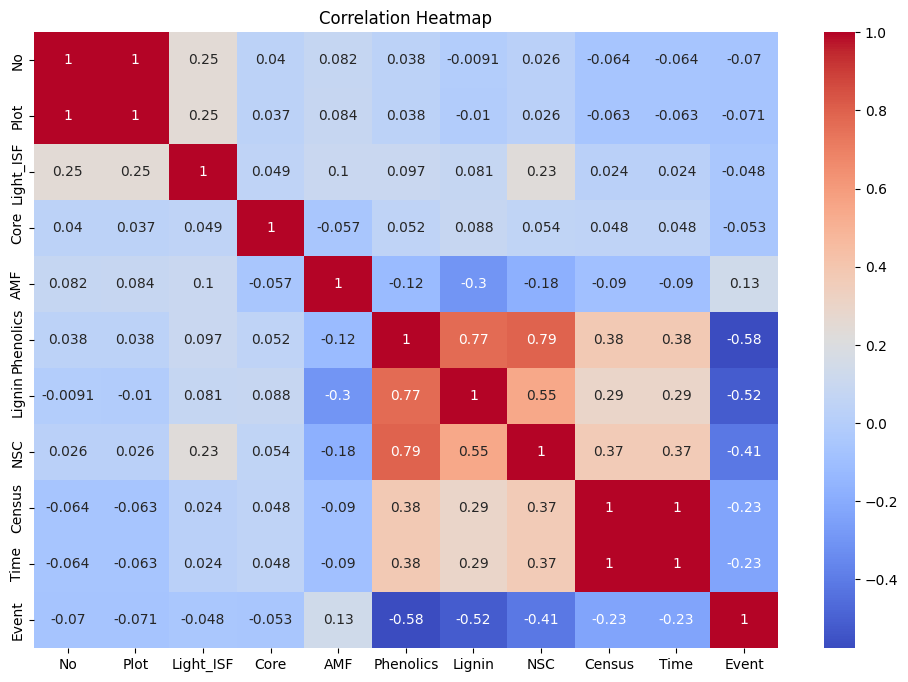

In [10]:
#Exploratory Data Analysis
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

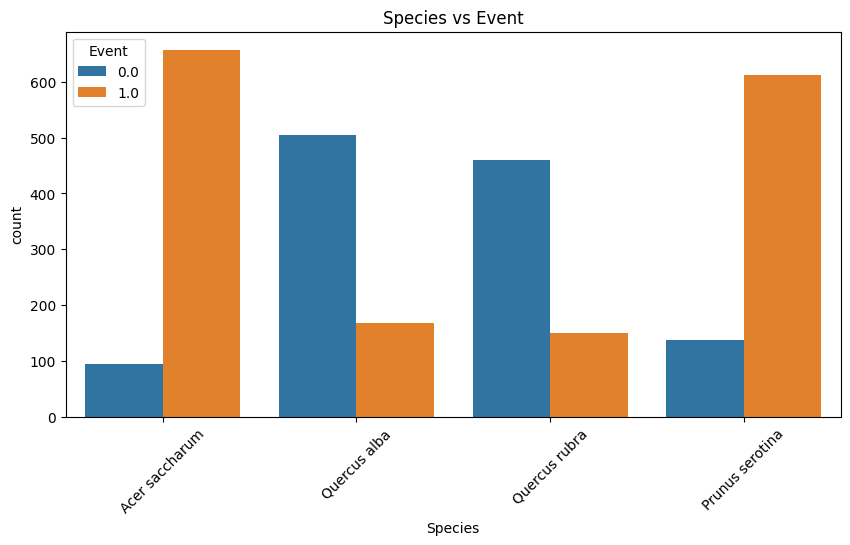

In [11]:
# Step 10: Relationship Between Species and Event
plt.figure(figsize=(10, 5))
sns.countplot(x="Species", hue="Event", data=df)
plt.title("Species vs Event")
plt.xticks(rotation=45)
plt.show()

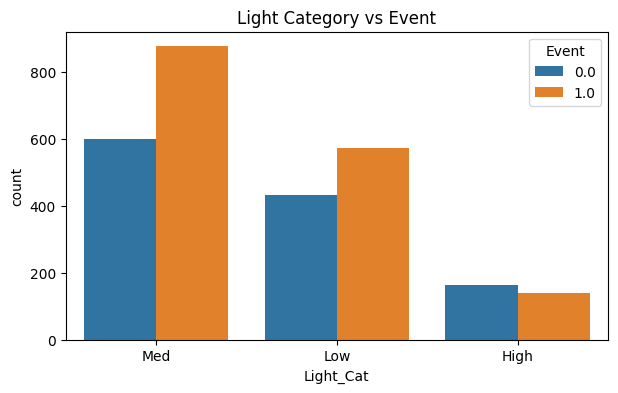

In [12]:
# Step 11: Relationship Between Light Category and Event
plt.figure(figsize=(7, 4))
sns.countplot(x="Light_Cat", hue="Event", data=df)
plt.title("Light Category vs Event")
plt.show()

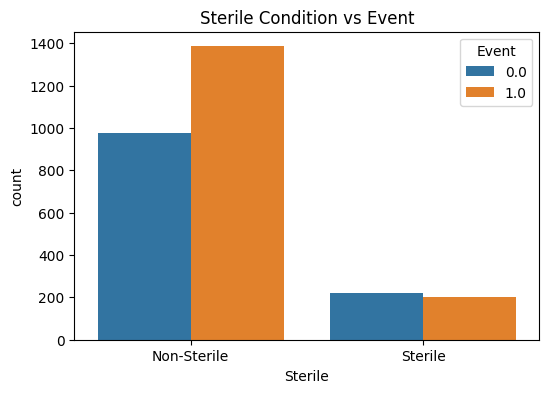

In [13]:
# Step 12: Relationship Between Sterile Condition and Event
plt.figure(figsize=(6, 4))
sns.countplot(x="Sterile", hue="Event", data=df)
plt.title("Sterile Condition vs Event")
plt.show()

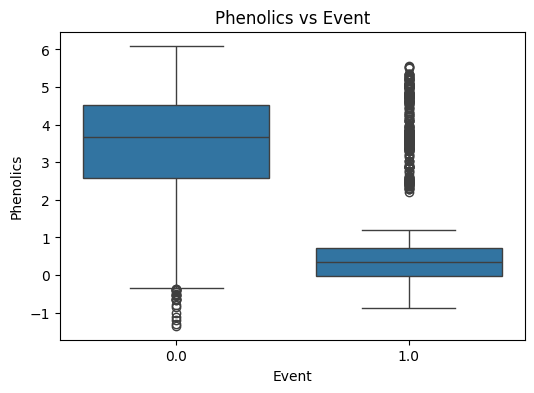

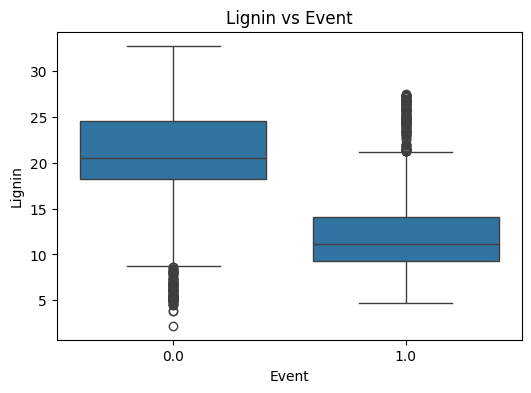

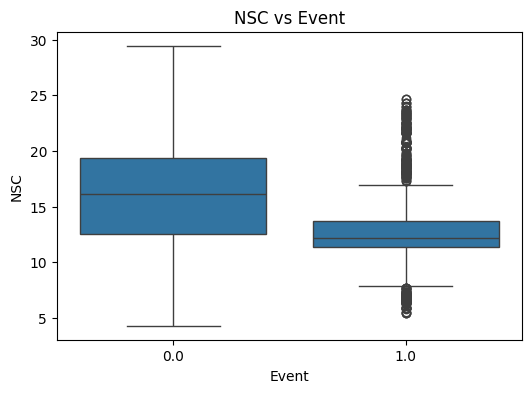

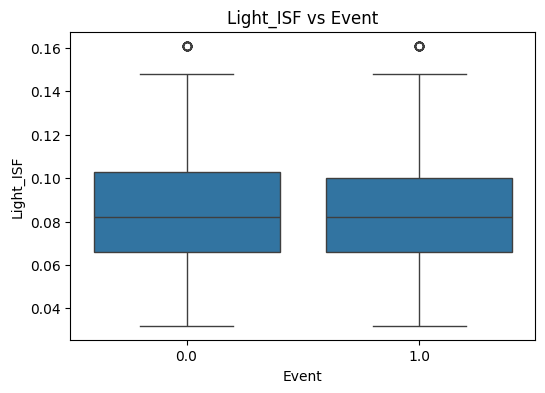

In [14]:
#Boxplot of Important Numerical Features
important_features = ["Phenolics", "Lignin", "NSC", "Light_ISF"]
for feature in important_features:
    if feature in df.columns:
        plt.figure(figsize=(6, 4))
        sns.boxplot(x="Event", y=feature, data=df)
        plt.title(f"{feature} vs Event")
        plt.show()

In [15]:
#Handle Missing Values
# Separate target variable
X = df.drop("Event", axis=1)
y = df["Event"]

# Identify categorical and numerical columns again
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

# Impute numerical columns using median
num_imputer = SimpleImputer(strategy="median")
X[numerical_cols] = num_imputer.fit_transform(X[numerical_cols])

# Impute categorical columns using most frequent value
cat_imputer = SimpleImputer(strategy="most_frequent")
X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

print("Missing values after imputation:")
print(X.isnull().sum())

Missing values after imputation:
No             0
Plot           0
Subplot        0
Species        0
Light_ISF      0
Light_Cat      0
Core           0
Soil           0
Adult          0
Sterile        0
Conspecific    0
Myco           0
SoilMyco       0
PlantDate      0
AMF            0
Phenolics      0
Lignin         0
NSC            0
Census         0
Time           0
dtype: int64


In [16]:

#Encode Categorical Columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
print("Data after encoding:")
display(X.head())

Data after encoding:


,No,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Soil,Adult,Sterile,Conspecific,Myco,SoilMyco,PlantDate,AMF,Phenolics,Lignin,NSC,Census,Time
0,126.0,1.0,2,0,0.106,2,2017.0,3,34,0,1,0,0,11,22.00,-0.56,13.86,12.15,4.0,14.0
1,11.0,1.0,2,2,0.106,2,2017.0,5,30,0,1,1,1,6,15.82,5.19,20.52,19.29,33.0,115.5
2,12.0,1.0,2,3,0.106,2,2017.0,3,35,0,1,1,0,9,24.45,3.36,24.74,15.01,18.0,63.0
3,2823.0,7.0,3,0,0.080,2,2016.0,3,35,0,1,0,0,11,22.23,-0.71,14.29,12.36,4.0,14.0
4,5679.0,14.0,0,0,0.060,1,2017.0,3,26,0,1,0,0,11,21.15,-0.58,10.85,11.20,4.0,14.0


In [17]:
#Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Feature scaling completed.")

Feature scaling completed.


In [18]:

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42, stratify=y)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (2225, 20)
Testing data shape: (557, 20)


In [19]:

# Create Function for Model Evaluation

model_results = {}

def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    model_results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUC Score": auc
    }

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("AUC Score:", auc)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"{model_name} AUC = {auc:.2f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.show()

Logistic Regression
Accuracy: 0.7827648114901257
Precision: 0.8361774744027304
Recall: 0.7704402515723271
F1 Score: 0.8019639934533551
AUC Score: 0.8110312886502986

Classification Report:
              precision    recall  f1-score   support

         0.0       0.72      0.80      0.76       239
         1.0       0.84      0.77      0.80       318

    accuracy                           0.78       557
   macro avg       0.78      0.78      0.78       557
weighted avg       0.79      0.78      0.78       557



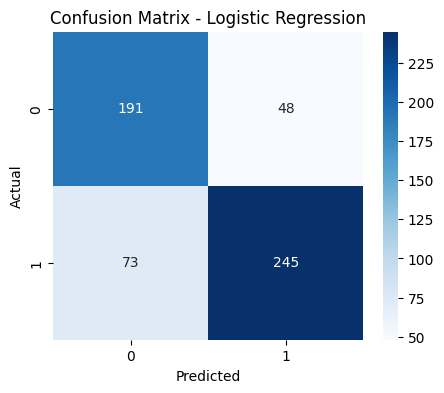

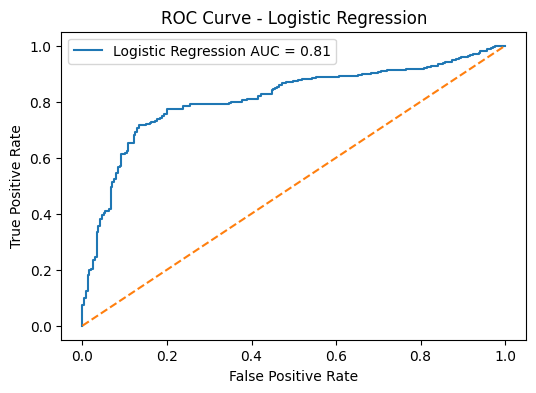

In [20]:
#Model 1 - Logistic Regression
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
log_model.fit(X_train, y_train)
evaluate_model("Logistic Regression", log_model, X_test, y_test)

Gaussian Naive Bayes
Accuracy: 0.7917414721723519
Precision: 0.8531468531468531
Recall: 0.7672955974842768
F1 Score: 0.8079470198675497
AUC Score: 0.8897134285939843

Classification Report:
              precision    recall  f1-score   support

         0.0       0.73      0.82      0.77       239
         1.0       0.85      0.77      0.81       318

    accuracy                           0.79       557
   macro avg       0.79      0.80      0.79       557
weighted avg       0.80      0.79      0.79       557



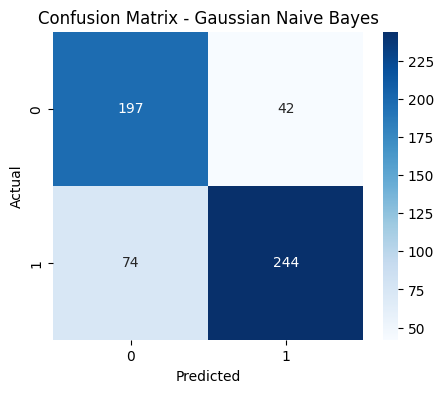

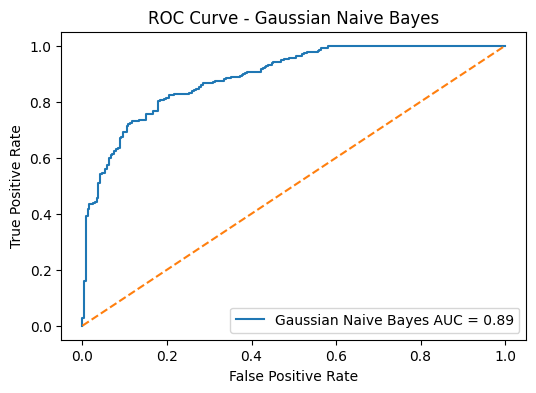

In [21]:
#Model 2 - Gaussian Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
evaluate_model("Gaussian Naive Bayes", nb_model, X_test, y_test)

In [22]:
# Step 23: Tune Epochs for Neural Network

epoch_list = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
epoch_results = []
for epoch in epoch_list:
    nn_temp_model = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=epoch,
        random_state=42
    )
    nn_temp_model.fit(X_train, y_train)
    y_pred = nn_temp_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    epoch_results.append({
        "Epoch": epoch,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })
    print(f"Epoch: {epoch}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("-" * 40)

Epoch: 100
Accuracy: 0.9282
Precision: 0.9484
Recall: 0.9245
F1 Score: 0.9363
----------------------------------------
Epoch: 200
Accuracy: 0.9264
Precision: 0.9482
Recall: 0.9214
F1 Score: 0.9346
----------------------------------------
Epoch: 300
Accuracy: 0.9192
Precision: 0.9446
Recall: 0.9119
F1 Score: 0.9280
----------------------------------------
Epoch: 400
Accuracy: 0.9228
Precision: 0.9421
Recall: 0.9214
F1 Score: 0.9316
----------------------------------------
Epoch: 500
Accuracy: 0.9228
Precision: 0.9421
Recall: 0.9214
F1 Score: 0.9316
----------------------------------------
Epoch: 600
Accuracy: 0.9228
Precision: 0.9421
Recall: 0.9214
F1 Score: 0.9316
----------------------------------------
Epoch: 700
Accuracy: 0.9228
Precision: 0.9421
Recall: 0.9214
F1 Score: 0.9316
----------------------------------------
Epoch: 800
Accuracy: 0.9228
Precision: 0.9421
Recall: 0.9214
F1 Score: 0.9316
----------------------------------------
Epoch: 900
Accuracy: 0.9228
Precision: 0.9421
Re

,Epoch,Accuracy,Precision,Recall,F1 Score
0,100,0.928187,0.948387,0.924528,0.936306
1,200,0.926391,0.948220,0.921384,0.934609
2,300,0.919210,0.944625,0.911950,0.928000
3,400,0.922801,0.942122,0.921384,0.931638
4,500,0.922801,0.942122,0.921384,0.931638
5,600,0.922801,0.942122,0.921384,0.931638
6,700,0.922801,0.942122,0.921384,0.931638
7,800,0.922801,0.942122,0.921384,0.931638
8,900,0.922801,0.942122,0.921384,0.931638
9,1000,0.922801,0.942122,0.921384,0.931638


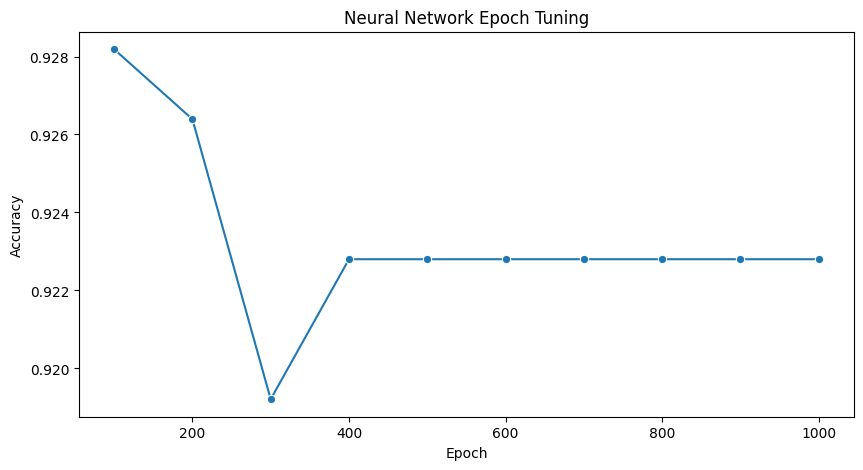

Best Epoch: 100
Best Epoch Accuracy: 0.9281867145421903


In [23]:
#Show Epoch Tuning Result
epoch_results_df = pd.DataFrame(epoch_results)
display(epoch_results_df)
plt.figure(figsize=(10, 5))
sns.lineplot(
    x="Epoch",
    y="Accuracy",
    data=epoch_results_df,
    marker="o"
)
plt.title("Neural Network Epoch Tuning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

best_epoch = epoch_results_df.loc[
    epoch_results_df["Accuracy"].idxmax(),
    "Epoch"
]
best_epoch_accuracy = epoch_results_df["Accuracy"].max()
print("Best Epoch:", best_epoch)
print("Best Epoch Accuracy:", best_epoch_accuracy)

Neural Network
Accuracy: 0.9281867145421903
Precision: 0.9483870967741935
Recall: 0.9245283018867925
F1 Score: 0.9363057324840764
AUC Score: 0.9849740796294834

Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.93      0.92       239
         1.0       0.95      0.92      0.94       318

    accuracy                           0.93       557
   macro avg       0.93      0.93      0.93       557
weighted avg       0.93      0.93      0.93       557



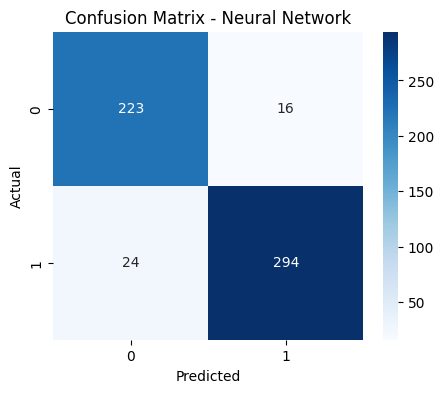

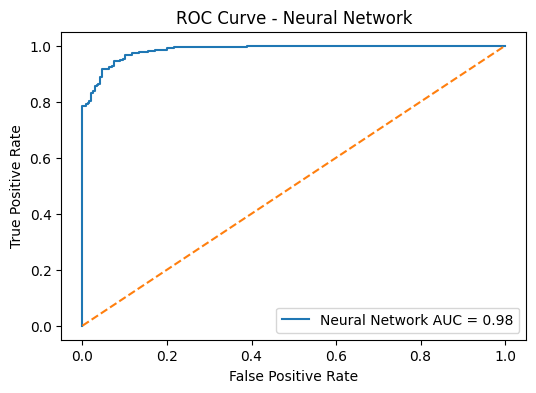

In [24]:
#Train Final Neural Network Using Best Epoch
nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=int(best_epoch),
    random_state=42
)

nn_model.fit(X_train, y_train)
evaluate_model("Neural Network", nn_model, X_test, y_test)

In [25]:
#Model Comparison Table
results_df = pd.DataFrame(model_results).T
display(results_df)

,Accuracy,Precision,Recall,F1 Score,AUC Score
Logistic Regression,0.782765,0.836177,0.770440,0.801964,0.811031
Gaussian Naive Bayes,0.791741,0.853147,0.767296,0.807947,0.889713
Neural Network,0.928187,0.948387,0.924528,0.936306,0.984974


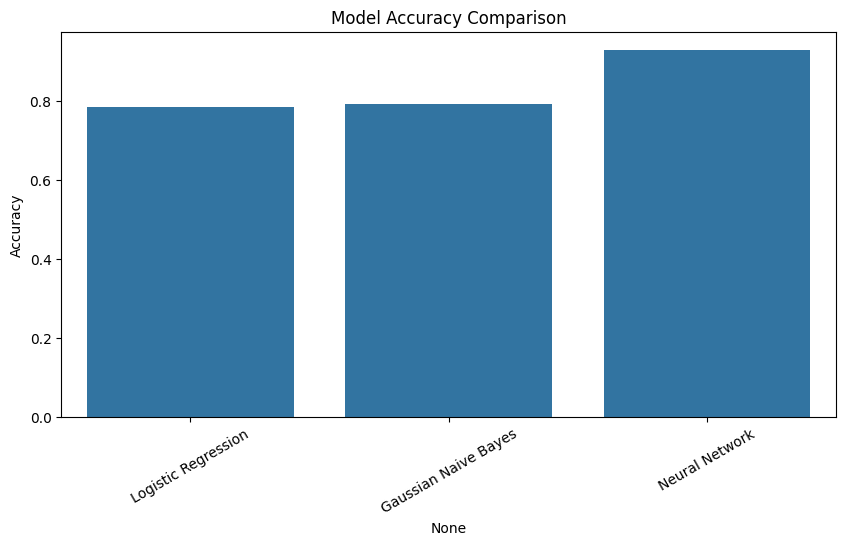

In [26]:
#Accuracy Comparison Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(x=results_df.index, y=results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

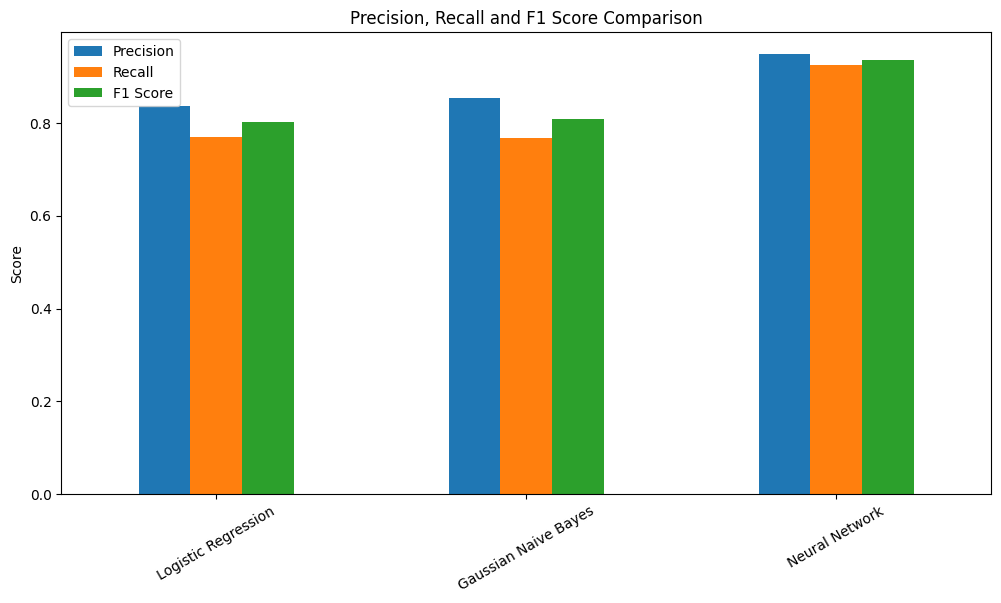

In [27]:
#Precision, Recall, F1 Score Comparison
results_df[["Precision", "Recall", "F1 Score"]].plot(kind="bar", figsize=(12, 6))
plt.title("Precision, Recall and F1 Score Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.show()

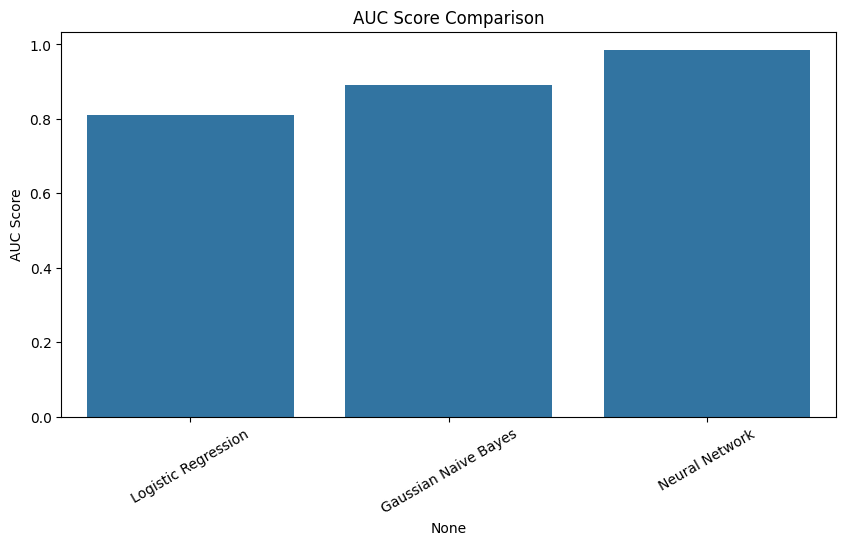

In [28]:
# Step 27: AUC Score Comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=results_df.index, y=results_df["AUC Score"])
plt.title("AUC Score Comparison")
plt.ylabel("AUC Score")
plt.xticks(rotation=30)
plt.show()

In [29]:
#KMeans Clustering
#Unsupervised Learning Part
kmeans_features = ["Phenolics", "Lignin", "NSC", "Light_ISF"]
available_kmeans_features = [col for col in kmeans_features if col in X.columns]
X_cluster = X[available_kmeans_features]
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)
df_cluster = df.copy()
df_cluster["Cluster"] = clusters
print("Cluster Counts:")
print(df_cluster["Cluster"].value_counts())

Cluster Counts:
Cluster
1    1501
0    1281
Name: count, dtype: int64


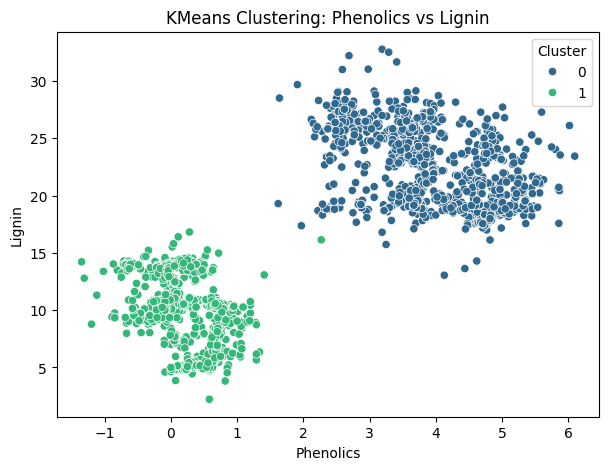

In [30]:
#Visualize KMeans Clusters
plt.figure(figsize=(7, 5))
sns.scatterplot(
    x=df_cluster["Phenolics"],
    y=df_cluster["Lignin"],
    hue=df_cluster["Cluster"],
    palette="viridis"
)
plt.title("KMeans Clustering: Phenolics vs Lignin")
plt.xlabel("Phenolics")
plt.ylabel("Lignin")
plt.show()

In [31]:
#Final Best Model
best_model_name = results_df["Accuracy"].idxmax()
best_accuracy = results_df["Accuracy"].max()
print("Best Performing Model:", best_model_name)
print("Best Accuracy:", best_accuracy)

Best Performing Model: Neural Network
Best Accuracy: 0.9281867145421903
